# Customer Churn Prediction

End-to-end ML pipeline using the Telco Customer Churn dataset.


## Cell 1 — Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, f1_score, accuracy_score)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import shap
import joblib

os.makedirs('../images', exist_ok=True)
os.makedirs('../models', exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("All libraries loaded successfully.")


All libraries loaded successfully.


## Cell 2 — Data Loading

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print()
print("Head:")
print(df.head(5))
print()
print("Dtypes:")
print(df.dtypes)
print()
print("Null counts:")
print(df.isnull().sum())

# Fix TotalCharges (whitespace strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
print()
print("TotalCharges fixed. New dtype:", df['TotalCharges'].dtype,
      "| nulls:", df['TotalCharges'].isnull().sum())


Shape: (7043, 21)

Head:


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## Cell 3 — Exploratory Data Analysis

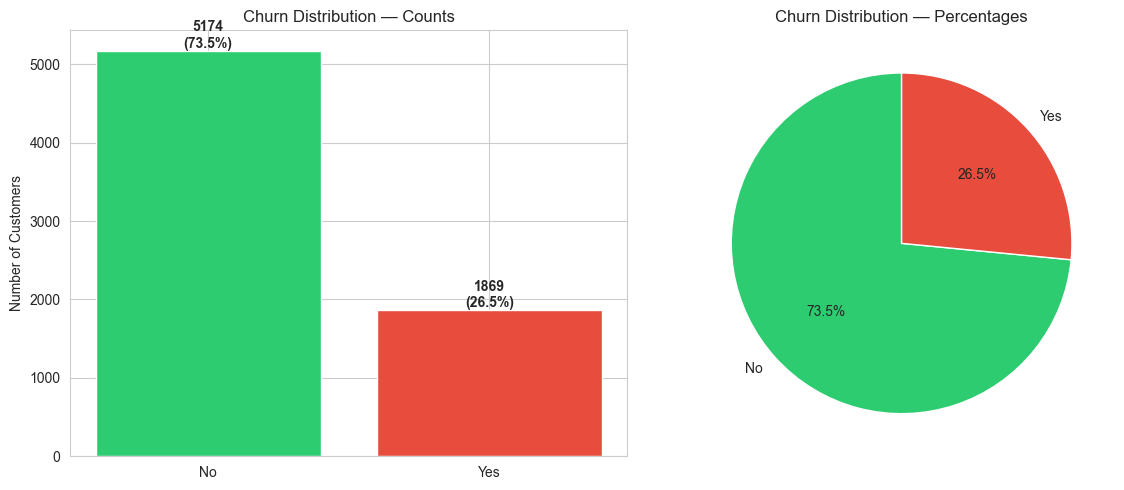

Insight: 26.5% of customers churned — class imbalance must be addressed (e.g., SMOTE).


In [3]:
# Plot 1 — churn_distribution.png
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df['Churn'].value_counts()
pct = counts / counts.sum() * 100

bars = axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution — Counts')
axes[0].set_ylabel('Number of Customers')
for b, c, p in zip(bars, counts.values, pct.values):
    axes[0].text(b.get_x() + b.get_width()/2, c, f"{c}\n({p:.1f}%)",
                 ha='center', va='bottom', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Distribution — Percentages')
plt.tight_layout()
plt.savefig('../images/churn_distribution.png', bbox_inches='tight')
plt.show()
print(f"Insight: {pct['Yes']:.1f}% of customers churned — class imbalance must be addressed (e.g., SMOTE).")


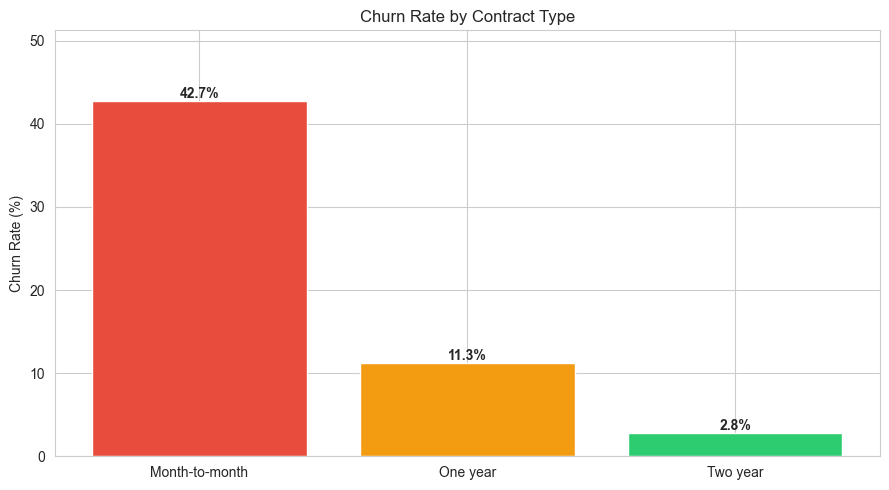

Insight: Month-to-month customers churn dramatically more than yearly contracts — locking customers in reduces churn.


In [4]:
# Plot 2 — churn_by_contract.png
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reindex(
    ['Month-to-month', 'One year', 'Two year'])

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(contract_churn.index, contract_churn.values, color=['#e74c3c', '#f39c12', '#2ecc71'])
ax.set_title('Churn Rate by Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, max(contract_churn.values) * 1.2)
for b, v in zip(bars, contract_churn.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/churn_by_contract.png', bbox_inches='tight')
plt.show()
print("Insight: Month-to-month customers churn dramatically more than yearly contracts — locking customers in reduces churn.")


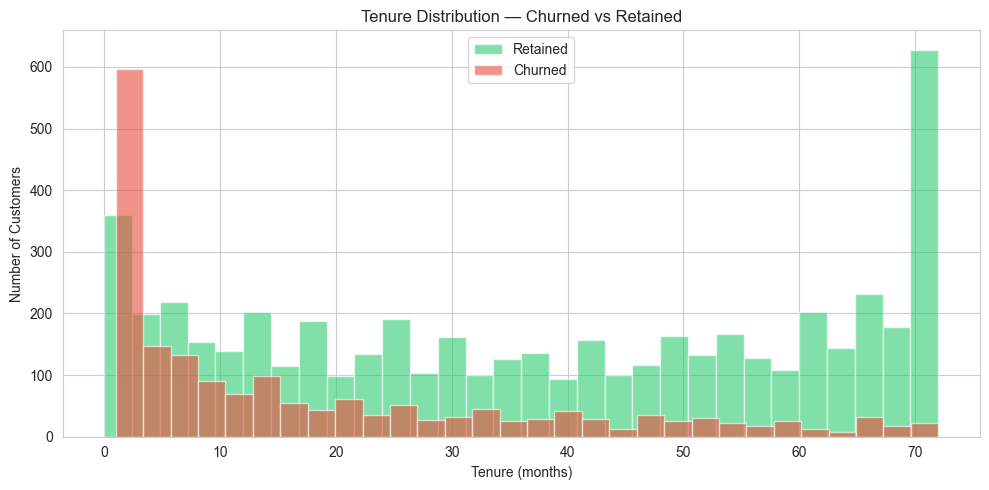

Insight: Most churners leave in their first few months — early-tenure customers need extra retention focus.


In [5]:
# Plot 3 — tenure_distribution.png
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[df['Churn']=='No']['tenure'], bins=30, alpha=0.6, label='Retained', color='#2ecc71')
ax.hist(df[df['Churn']=='Yes']['tenure'], bins=30, alpha=0.6, label='Churned', color='#e74c3c')
ax.set_title('Tenure Distribution — Churned vs Retained')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.savefig('../images/tenure_distribution.png', bbox_inches='tight')
plt.show()
print("Insight: Most churners leave in their first few months — early-tenure customers need extra retention focus.")


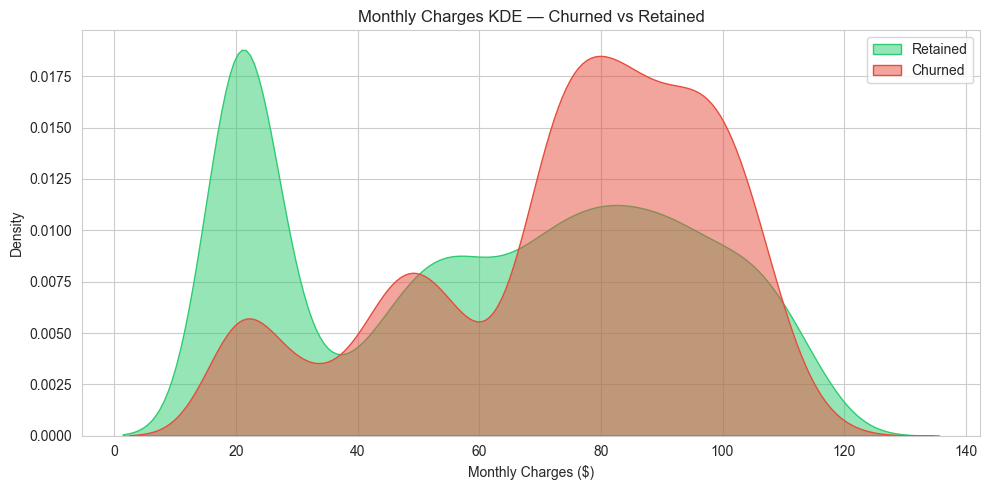

Insight: Churners skew toward higher monthly charges — premium pricing without perceived value drives attrition.


In [6]:
# Plot 4 — monthly_charges_kde.png
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(df[df['Churn']=='No']['MonthlyCharges'], fill=True, alpha=0.5, label='Retained', color='#2ecc71', ax=ax)
sns.kdeplot(df[df['Churn']=='Yes']['MonthlyCharges'], fill=True, alpha=0.5, label='Churned', color='#e74c3c', ax=ax)
ax.set_title('Monthly Charges KDE — Churned vs Retained')
ax.set_xlabel('Monthly Charges ($)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/monthly_charges_kde.png', bbox_inches='tight')
plt.show()
print("Insight: Churners skew toward higher monthly charges — premium pricing without perceived value drives attrition.")


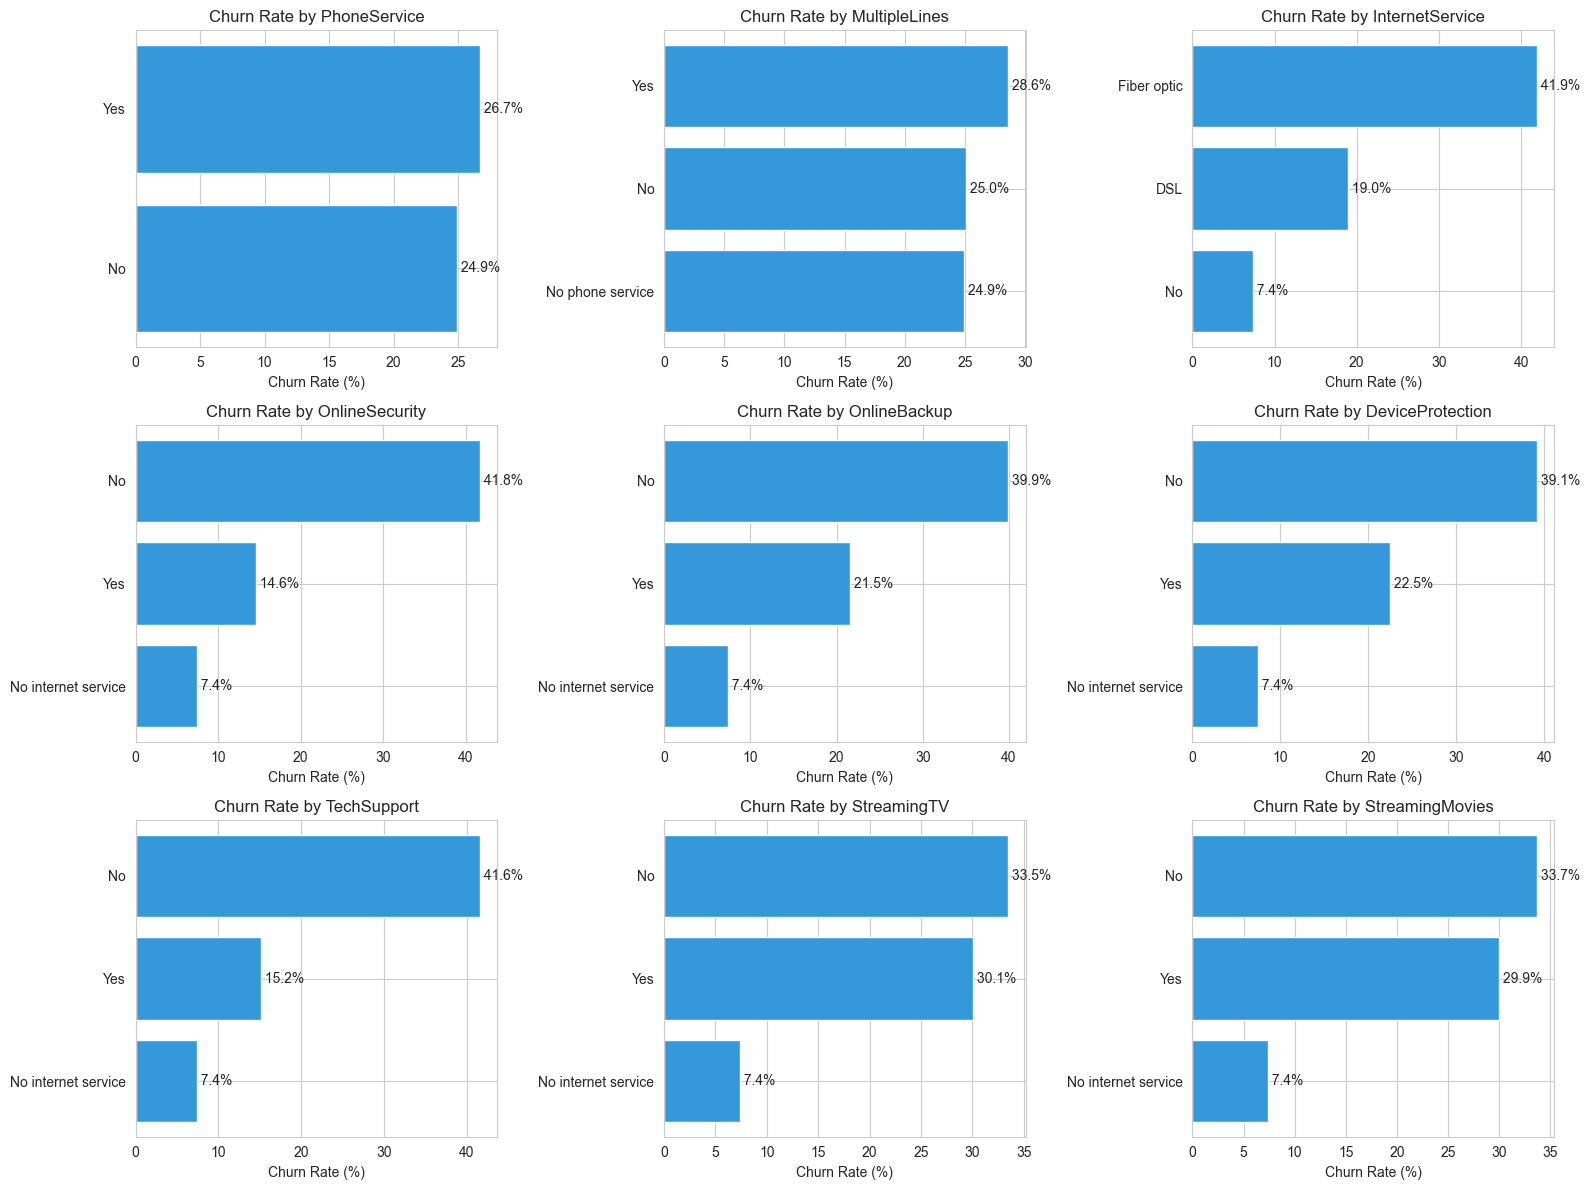

Insight: Customers without TechSupport, OnlineSecurity, or OnlineBackup churn far more — bundling protective services lowers churn risk.


In [7]:
# Plot 5 — churn_by_services.png (3x3 grid)
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), service_cols):
    rates = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()*100).sort_values()
    ax.barh(rates.index, rates.values, color='#3498db')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_xlabel('Churn Rate (%)')
    for i, v in enumerate(rates.values):
        ax.text(v, i, f" {v:.1f}%", va='center')
plt.tight_layout()
plt.savefig('../images/churn_by_services.png', bbox_inches='tight')
plt.show()
print("Insight: Customers without TechSupport, OnlineSecurity, or OnlineBackup churn far more — bundling protective services lowers churn risk.")


## Cell 4 — Feature Engineering

In [8]:
data = df.copy()
data = data.drop(columns=['customerID'])

# Target
data['Churn'] = (data['Churn'] == 'Yes').astype(int)

# Binary encodings
for c in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    data[c] = (data[c] == 'Yes').astype(int)
data['gender'] = (data['gender'] == 'Male').astype(int)

# One-hot encodings (drop_first=True)
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod']
data = pd.get_dummies(data, columns=ohe_cols, drop_first=True)

# Cast bool dummies to int for downstream stability
for c in data.select_dtypes(include='bool').columns:
    data[c] = data[c].astype(int)

print("Final shape:", data.shape)
print()
print("Feature names:")
for f in data.columns:
    print(" -", f)


Final shape: (7043, 31)

Feature names:
 - gender
 - SeniorCitizen
 - Partner
 - Dependents
 - tenure
 - PhoneService
 - PaperlessBilling
 - MonthlyCharges
 - TotalCharges
 - Churn
 - MultipleLines_No phone service
 - MultipleLines_Yes
 - InternetService_Fiber optic
 - InternetService_No
 - OnlineSecurity_No internet service
 - OnlineSecurity_Yes
 - OnlineBackup_No internet service
 - OnlineBackup_Yes
 - DeviceProtection_No internet service
 - DeviceProtection_Yes
 - TechSupport_No internet service
 - TechSupport_Yes
 - StreamingTV_No internet service
 - StreamingTV_Yes
 - StreamingMovies_No internet service
 - StreamingMovies_Yes
 - Contract_One year
 - Contract_Two year
 - PaymentMethod_Credit card (automatic)
 - PaymentMethod_Electronic check
 - PaymentMethod_Mailed check


## Cell 5 — Preprocessing & SMOTE

In [9]:
X = data.drop(columns=['Churn'])
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric columns (fit on train only)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Class counts BEFORE SMOTE:")
print(y_train.value_counts())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print()
print("Class counts AFTER SMOTE:")
print(pd.Series(y_train_res).value_counts())


Class counts BEFORE SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64



Class counts AFTER SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


## Cell 6 — Model Training & Comparison

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                             random_state=42, eval_metric='logloss', use_label_encoder=False)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print("=" * 70)
    print(f"Training: {name}")
    print("=" * 70)
    cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='roc_auc', n_jobs=-1)
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, y_proba)
    test_f1 = f1_score(y_test, y_pred)
    test_acc = accuracy_score(y_test, y_pred)

    results[name] = {
        'cv_auc_mean': cv_scores.mean(), 'cv_auc_std': cv_scores.std(),
        'test_auc': test_auc, 'f1': test_f1, 'acc': test_acc,
        'y_proba': y_proba, 'model': model
    }

    print(f"CV ROC-AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Test ROC-AUC: {test_auc:.4f}")
    print(f"F1-Score   : {test_f1:.4f}")
    print(f"Accuracy   : {test_acc:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))


Training: Logistic Regression


CV ROC-AUC : 0.8870 ± 0.0049
Test ROC-AUC: 0.8355
F1-Score   : 0.6249
Accuracy   : 0.7622

              precision    recall  f1-score   support

    Retained       0.89      0.77      0.83      1035
     Churned       0.54      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

Training: Random Forest


CV ROC-AUC : 0.9177 ± 0.0067
Test ROC-AUC: 0.8202
F1-Score   : 0.5898
Accuracy   : 0.7651

              precision    recall  f1-score   support

    Retained       0.86      0.81      0.84      1035
     Churned       0.55      0.64      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409

Training: XGBoost


CV ROC-AUC : 0.9008 ± 0.0058
Test ROC-AUC: 0.8245
F1-Score   : 0.6102
Accuracy   : 0.7615

              precision    recall  f1-score   support

    Retained       0.88      0.78      0.83      1035
     Churned       0.54      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



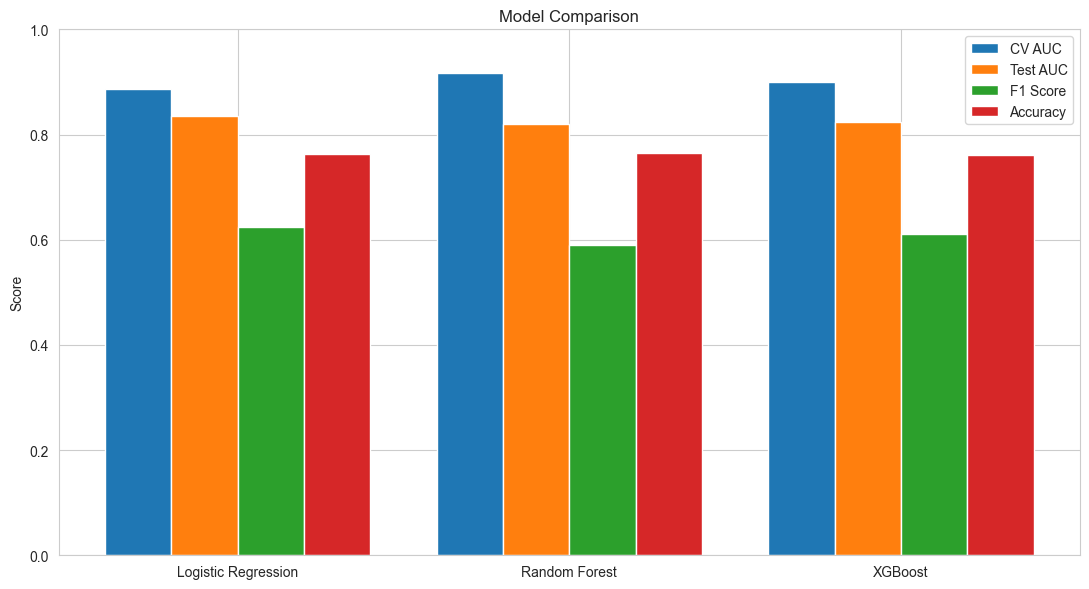

In [11]:
# model_comparison.png
metrics_df = pd.DataFrame({
    'Model': list(results.keys()),
    'CV AUC': [r['cv_auc_mean'] for r in results.values()],
    'Test AUC': [r['test_auc'] for r in results.values()],
    'F1 Score': [r['f1'] for r in results.values()],
    'Accuracy': [r['acc'] for r in results.values()]
})

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(metrics_df))
width = 0.2
for i, m in enumerate(['CV AUC', 'Test AUC', 'F1 Score', 'Accuracy']):
    ax.bar(x + i*width, metrics_df[m], width, label=m)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics_df['Model'])
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('../images/model_comparison.png', bbox_inches='tight')
plt.show()


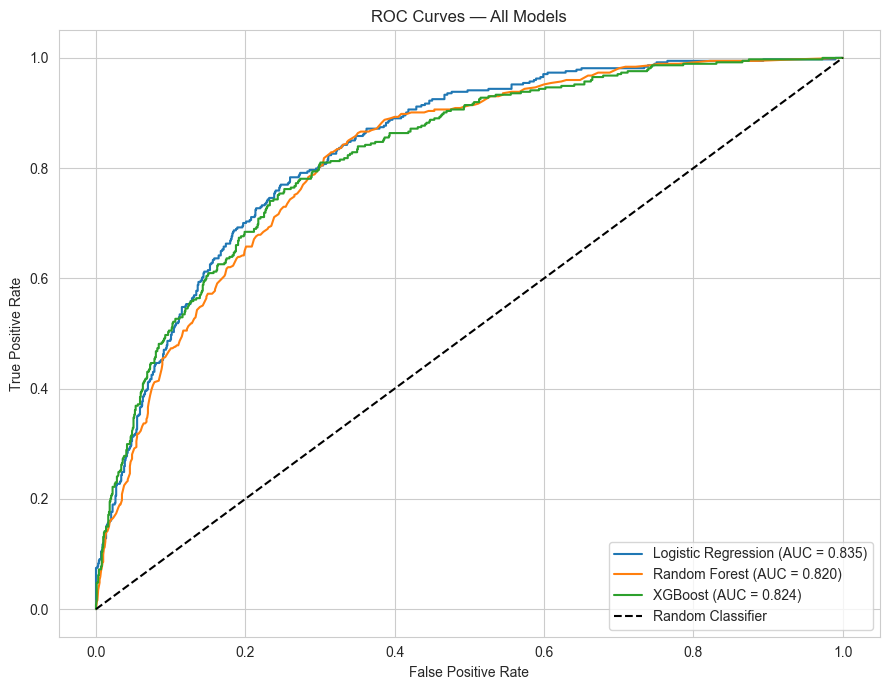

In [12]:
# roc_curves.png
fig, ax = plt.subplots(figsize=(9, 7))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {r['test_auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../images/roc_curves.png', bbox_inches='tight')
plt.show()


## Cell 7 — Hyperparameter Tuning (XGBoost)

In [13]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
grid = GridSearchCV(
    xgb, param_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1, verbose=1
)
grid.fit(X_train_res, y_train_res)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print()
print("Tuned XGBoost on test set:")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))


Fitting 5 folds for each of 108 candidates, totalling 540 fits


Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best CV ROC-AUC: 0.9139563848096476

Tuned XGBoost on test set:
ROC-AUC : 0.8080
F1-Score: 0.5914
Accuracy: 0.7637

              precision    recall  f1-score   support

    Retained       0.86      0.81      0.83      1035
     Churned       0.55      0.64      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409



## Cell 8 — Detailed Evaluation

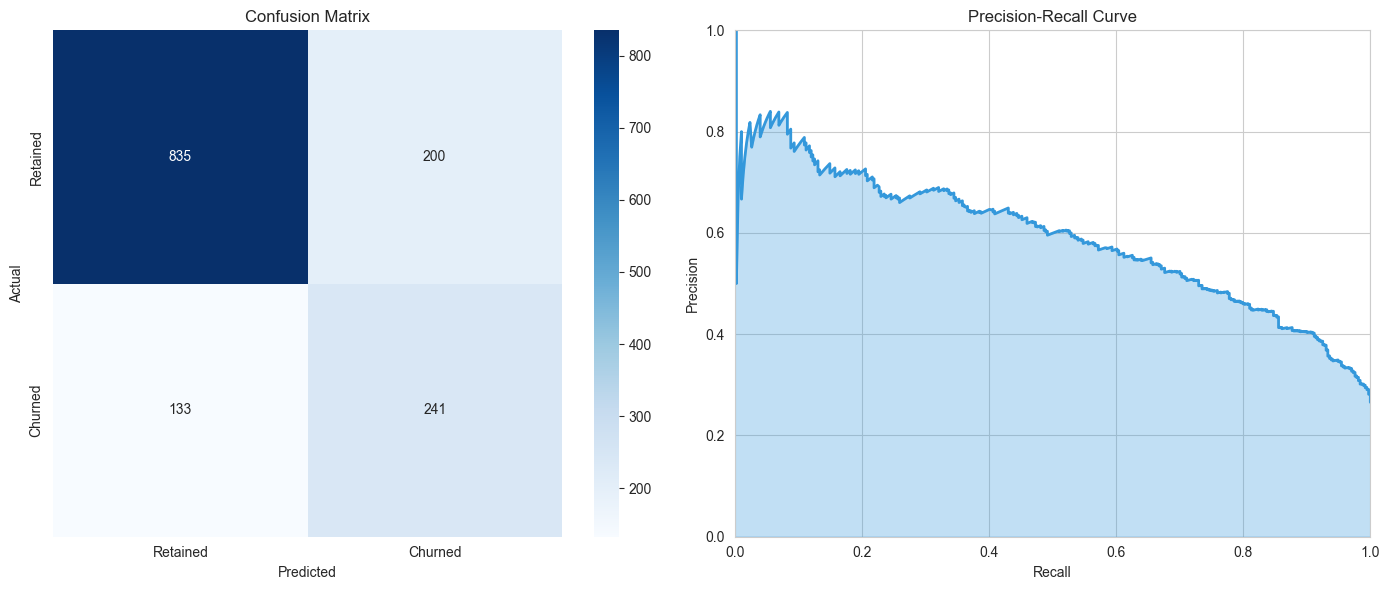

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec, prec, color='#3498db', linewidth=2)
axes[1].fill_between(rec, prec, alpha=0.3, color='#3498db')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../images/evaluation_detailed.png', bbox_inches='tight')
plt.show()


## Cell 9 — SHAP Explainability

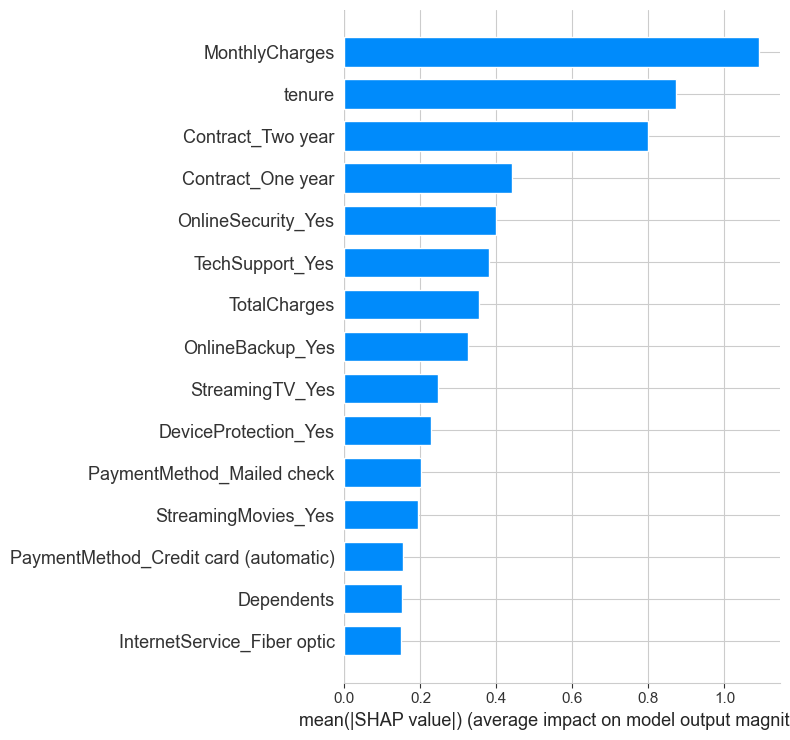

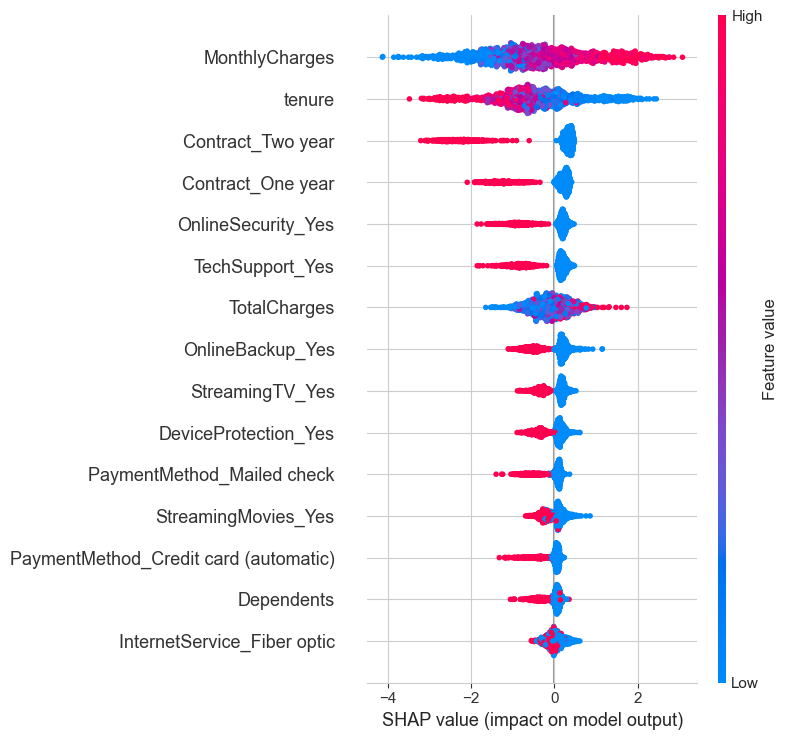

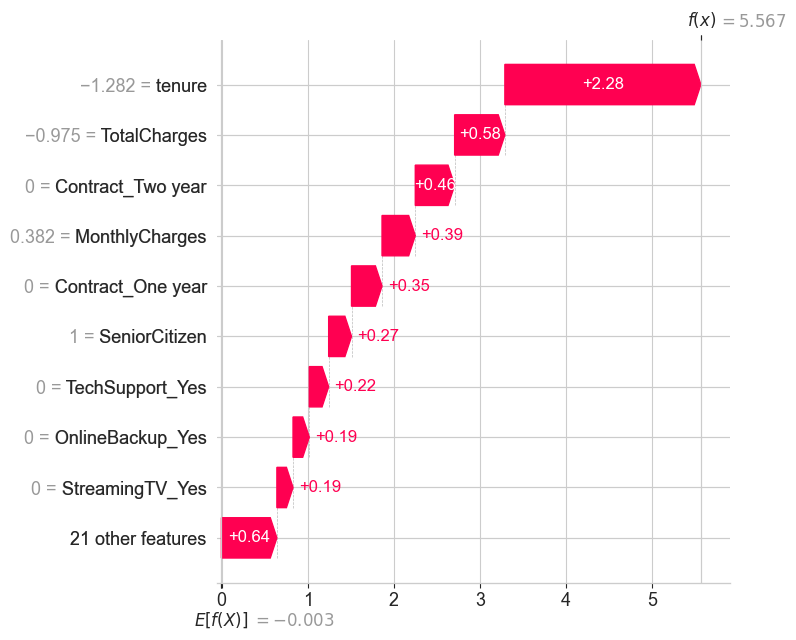

Highest-risk customer index: 618
Predicted churn probability: 0.9962
Actual label: Churned


In [15]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Bar summary
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15, show=False)
plt.tight_layout()
plt.savefig('../images/shap_feature_importance.png', bbox_inches='tight')
plt.show()

# Beeswarm
plt.figure()
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.tight_layout()
plt.savefig('../images/shap_beeswarm.png', bbox_inches='tight')
plt.show()

# Waterfall for highest-risk customer
idx = int(np.argmax(y_proba))
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(np.array(expected_value).flatten()[0])

explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=expected_value,
    data=X_test.iloc[idx].values,
    feature_names=list(X_test.columns)
)
plt.figure()
shap.plots.waterfall(explanation, max_display=10, show=False)
plt.tight_layout()
plt.savefig('../images/shap_waterfall.png', bbox_inches='tight')
plt.show()

print(f"Highest-risk customer index: {idx}")
print(f"Predicted churn probability: {y_proba[idx]:.4f}")
print(f"Actual label: {'Churned' if y_test.iloc[idx]==1 else 'Retained'}")


## Cell 10 — Save Artifacts

In [16]:
joblib.dump(best_model,          '../models/churn_model.pkl')
joblib.dump(scaler,              '../models/scaler.pkl')
joblib.dump(list(X.columns),     '../models/feature_names.pkl')

print("Saved:")
print(" - ../models/churn_model.pkl")
print(" - ../models/scaler.pkl")
print(" - ../models/feature_names.pkl")


Saved:
 - ../models/churn_model.pkl
 - ../models/scaler.pkl
 - ../models/feature_names.pkl


## Cell 11 — Notebook Summary

In [17]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:5]
top_features = [(X_test.columns[i], float(mean_abs_shap[i])) for i in top_idx]

img_count = len([f for f in os.listdir('../images') if f.endswith('.png')])
model_count = len([f for f in os.listdir('../models') if f.endswith('.pkl')])

print("=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)
print(f"Best model       : XGBoost (tuned)")
print(f"Test ROC-AUC     : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Test F1 Score    : {f1_score(y_test, y_pred):.4f}")
print()
print("Top 5 features (by mean |SHAP|):")
for name, val in top_features:
    print(f"  - {name:<35} {val:.4f}")
print()
print(f"Images saved      : {img_count}")
print(f"Model artifacts   : {model_count}")
print("=" * 60)


PROJECT SUMMARY
Best model       : XGBoost (tuned)
Test ROC-AUC     : 0.8080
Test F1 Score    : 0.5914

Top 5 features (by mean |SHAP|):
  - MonthlyCharges                      1.0916
  - tenure                              0.8719
  - Contract_Two year                   0.7984
  - Contract_One year                   0.4404
  - OnlineSecurity_Yes                  0.3985

Images saved      : 11
Model artifacts   : 3
